
# MNIST MLP + Gradient Covariance + Hessian Density

This notebook implements:

1. MNIST classification
2. MLP (1024, 1024)
3. Training loop
4. Accuracy evaluation
5. Gradient covariance matrix (Equation 3 from Lyle et al.)
6. Gradient covariance heatmap
7. Hessian density estimation using PyHessian
8. Hessian density visualization

This notebook is intended as a first validation step before reproducing the full plasticity experiments.


## Install Dependencies

In [ ]:

# Uncomment if needed

# !pip install pyhessian
# !pip install seaborn


## Imports

In [2]:

import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import seaborn as sns

from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader, Subset


## Reproducibility

In [3]:

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)


Device: cpu


## MNIST Dataset

In [4]:

transform = transforms.ToTensor()

mnist = MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

subset = Subset(
    mnist,
    range(5000)
)

train_loader = DataLoader(
    subset,
    batch_size=128,
    shuffle=True
)

print("Dataset size:", len(subset))


Dataset size: 5000


## MLP Architecture (1024,1024)

In [5]:

class MLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(784, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 10)

        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()

    def forward(self, x):

        x = x.view(x.size(0), -1)

        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))

        return self.fc3(x)


## Model

In [6]:

model = MLP().to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

print(model)


MLP(
  (fc1): Linear(in_features=784, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=1024, bias=True)
  (fc3): Linear(in_features=1024, out_features=10, bias=True)
  (relu1): ReLU()
  (relu2): ReLU()
)


## Accuracy Function

In [7]:

@torch.no_grad()
def compute_accuracy(model, loader):

    model.eval()

    correct = 0
    total = 0

    for x, y in loader:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(x)

        preds = logits.argmax(1)

        correct += (preds == y).sum().item()
        total += y.size(0)

    return correct / total


## Training

In [8]:

EPOCHS = 5

loss_history = []
accuracy_history = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for x, y in train_loader:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(logits, y)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    acc = compute_accuracy(
        model,
        train_loader
    )

    loss_history.append(running_loss)
    accuracy_history.append(acc)

    print(
        f"Epoch {epoch+1} | "
        f"Loss={running_loss:.3f} | "
        f"Acc={acc:.4f}"
    )


Epoch 1 | Loss=29.517 | Acc=0.9126
Epoch 2 | Loss=10.234 | Acc=0.9518
Epoch 3 | Loss=6.302 | Acc=0.9802
Epoch 4 | Loss=3.739 | Acc=0.9812
Epoch 5 | Loss=2.594 | Acc=0.9866


## Training Curves

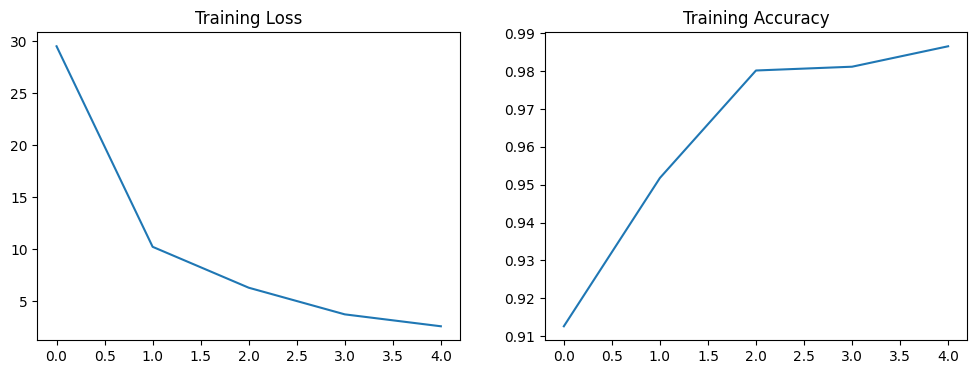

In [9]:

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(loss_history)
plt.title("Training Loss")

plt.subplot(1,2,2)
plt.plot(accuracy_history)
plt.title("Training Accuracy")

plt.show()


## Gradient Covariance (Equation 3)

In [10]:

def flatten_gradients(model):

    grads = []

    for p in model.parameters():

        if p.grad is not None:
            grads.append(
                p.grad.flatten()
            )

    return torch.cat(grads)


In [13]:

batch = next(iter(train_loader))

inputs, targets = batch

inputs = inputs[:64].to(DEVICE)
targets = targets[:64].to(DEVICE)

gradient_vectors = []

for i in range(len(inputs)):

    model.zero_grad()

    x = inputs[i:i+1]
    y = targets[i:i+1]

    output = model(x)

    loss = criterion(output, y)

    loss.backward()

    gradient_vectors.append(
        flatten_gradients(model)
    )

G = torch.stack(gradient_vectors)

G = F.normalize(
    G,
    p=2,
    dim=1
)

C = G @ G.T

print(C.shape)


torch.Size([64, 64])


## Gradient Covariance Heatmap

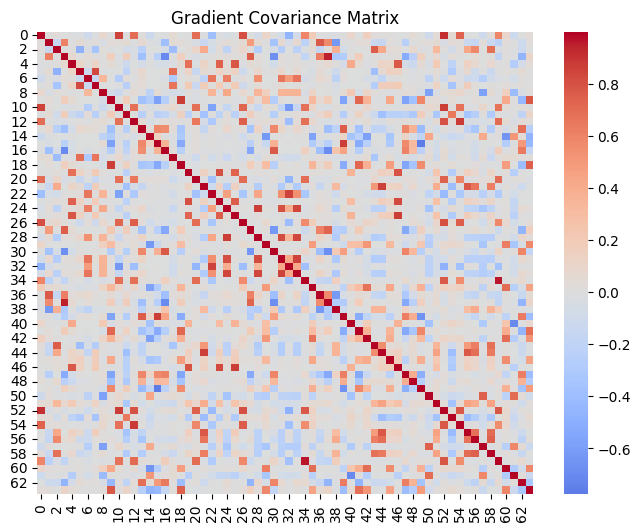

In [14]:

plt.figure(figsize=(8,6))

sns.heatmap(
    C.detach().cpu().numpy(),
    cmap='coolwarm',
    center=0
)

plt.title(
    'Gradient Covariance Matrix'
)

plt.show()



## Hessian Density

PyHessian implements:
- Hessian-vector products
- Lanczos iterations
- Spectral density estimation

following the same general methodology used by:

Ghorbani et al. (2019)


In [15]:

# Uncomment once pyhessian is installed

from pyhessian import hessian


## Compute Hessian Density

In [ ]:

batch = next(iter(train_loader))

inputs, targets = batch

inputs = inputs.to(DEVICE)
targets = targets.to(DEVICE)

hessian_comp = hessian(
    model,
    criterion,
    data=(inputs, targets),
    cuda=False,
)

density_eigen, density_weight = hessian_comp.density(iter=100, n_v=1)


/Users/mahdigheidi/Documents/Univ/Masters-Study-Project/venv/lib/python3.13/site-packages/torch/autograd/graph.py:882: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/engine.cpp:1304.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


RuntimeError: This function was deprecated since version 1.9 and is now removed. `torch.linalg.eig` returns complex tensors of dtype `cfloat` or `cdouble` rather than real tensors mimicking complex tensors.

L, _ = torch.eig(A) should be replaced with:
L_complex = torch.linalg.eigvals(A)

and

L, V = torch.eig(A, eigenvectors=True) should be replaced with:
L_complex, V_complex = torch.linalg.eig(A)

## Plot Hessian Density

In [ ]:

plt.figure(figsize=(8,5))

plt.plot(
    density_eigen,
    density_weight
)

plt.xlabel("Eigenvalue")

plt.ylabel("Density")

plt.title(
    "Hessian Eigenvalue Density"
)

plt.show()



## Expected Outputs

After training:

### Gradient Covariance

You should observe:

- positive blocks
- negative interference regions
- sample alignment structure

### Hessian Density

You should observe:

- a large bulk near zero
- a positive tail
- a few large eigenvalues

These are the first geometric diagnostics used throughout the plasticity paper.
